# Live session run

End-to-end CNMFe run on a real recording sitting on the server. Edit
`SESSION_RAW` and the `SSUB` / `TSUB` downsample factors, then step through.

**Path layout** (mirrors the standard `0_raw / 1_preprocessed / 2_processed`
project tree):

- `0_raw/<session>/miniscope_video/*.avi`                  — source AVIs (read-only)
- `1_preprocessed/<session>/miniscope_video/mc.zarr`       — motion-corrected zarr (the ONLY zarr written)
- `1_preprocessed/<session>/miniscope_video/shifts.npy`    — per-frame (dy, dx)
- `2_processed/<session>/miniscope_video/mc_plots/`        — diagnostic plots
- `2_processed/<session>/miniscope_video/mc_downsampled.mp4` — every Nth frame, visual QC
- `2_processed/<session>/miniscope_video/results/`         — CNMFe output (A, C, S, YrA, ...)

**Fused, single write — decode + (optional) downsample + motion-correct in one
pass.** `CNMFe.fit_mc_from_avis(..., ssub=SSUB, tsub=TSUB)` decodes the AVIs,
block-mean bins them inline when `SSUB`/`TSUB` > 1, and applies rigid motion
correction — writing only `mc.zarr` (no intermediate `session.zarr` / `ds.zarr`).
Spatial binning averages `SSUB×SSUB` pixel blocks; temporal binning averages
`TSUB` consecutive frames per file. Everything after runs on that movie;
parameters are rescaled to its grid via `CNMFeParams.downscaled(SSUB, TSUB)`.
Outputs stay at the downsampled resolution.

Temporal binning happens **before** MC by design (fine for slow drift / small
`TSUB`; see CLAUDE.md). **Extraction uses the staged API:** `fit_extract(...)`
then `evaluate()` (equivalent to one `CNMFe.fit(..., do_motion_correction=False)`).

Each step is **idempotent**: if its output exists, the cell reuses it. Delete
the file/folder on disk to redo a step.

## 1. Imports

In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Make the project root importable so 'concat_avis_to_zarr' resolves when
# running the notebook from anywhere.
PROJECT_ROOT = Path('/home/fs539/code/simpler_cnmfe')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from cnmfe.io import open_zarr
from cnmfe.pipeline import CNMFe, CNMFeParams
from concat_avis_to_zarr import concat_avis_to_zarr, _count_and_shape, _numeric_key

## 2. Session paths + downsample factors

Set `SESSION_RAW` to the raw `miniscope_video` folder; `1_preprocessed` and
`2_processed` are derived by replacing the `0_raw` segment. `SSUB` / `TSUB` are
the spatial / temporal bin factors (1 = no downsampling).

In [2]:
# --- EDIT ME -----------------------------------------------------------------
SESSION_RAW = Path(
    '/media/server/archive/projects/2023_intercontext/ToneComparison/'
    'data/0_raw/20260520_m0000159_som_1145/miniscope_video'
)
SSUB = 2    # spatial bin factor  (1 = no spatial downsampling)
TSUB = 2    # temporal bin factor (1 = no temporal downsampling)
# -----------------------------------------------------------------------------

def _swap_stage(p: Path, new_stage: str) -> Path:
    # Replace the '0_raw' segment with `new_stage` in a path.
    parts = list(p.parts)
    try:
        i = parts.index('0_raw')
    except ValueError as exc:
        raise ValueError(
            f"Expected '0_raw' in path {p}; can't derive {new_stage} location."
        ) from exc
    parts[i] = new_stage
    return Path(*parts)

SESSION_PREPROC = _swap_stage(SESSION_RAW, '1_preprocessed')
SESSION_PROC    = _swap_stage(SESSION_RAW, '2_processed')

DOWNSAMPLE  = (SSUB > 1 or TSUB > 1)
RAW_AVI_DIR = SESSION_RAW
MC_ZARR     = SESSION_PREPROC / 'mc.zarr'      # the only zarr written (fused)
SHIFTS_NPY  = SESSION_PREPROC / 'shifts.npy'
MC_PLOTS    = SESSION_PROC / 'mc_plots'
MC_MP4      = SESSION_PROC / 'mc_downsampled.mp4'
RESULTS_DIR = SESSION_PROC / 'results'

SESSION_PREPROC.mkdir(parents=True, exist_ok=True)
SESSION_PROC.mkdir(parents=True, exist_ok=True)
MC_PLOTS.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Raw AVIs  :', RAW_AVI_DIR)
print(f'Downsample : ssub={SSUB} tsub={TSUB}  ({"on" if DOWNSAMPLE else "off"})')
print('MC zarr  ->', MC_ZARR)
print('Shifts   ->', SHIFTS_NPY)
print('MC plots ->', MC_PLOTS)
print('MC mp4   ->', MC_MP4)
print('Results  ->', RESULTS_DIR)

assert RAW_AVI_DIR.is_dir(), f'Raw folder does not exist: {RAW_AVI_DIR}'

Raw AVIs  : /media/server/archive/projects/2023_intercontext/ToneComparison/data/0_raw/20260520_m0000159_som_1145/miniscope_video
Downsample : ssub=2 tsub=2  (on)
MC zarr  -> /media/server/archive/projects/2023_intercontext/ToneComparison/data/1_preprocessed/20260520_m0000159_som_1145/miniscope_video/mc.zarr
Shifts   -> /media/server/archive/projects/2023_intercontext/ToneComparison/data/1_preprocessed/20260520_m0000159_som_1145/miniscope_video/shifts.npy
MC plots -> /media/server/archive/projects/2023_intercontext/ToneComparison/data/2_processed/20260520_m0000159_som_1145/miniscope_video/mc_plots
MC mp4   -> /media/server/archive/projects/2023_intercontext/ToneComparison/data/2_processed/20260520_m0000159_som_1145/miniscope_video/mc_downsampled.mp4
Results  -> /media/server/archive/projects/2023_intercontext/ToneComparison/data/2_processed/20260520_m0000159_som_1145/miniscope_video/results


## 3. Discover AVIs + light raw inspection

List the numbered AVIs and pull a few sample frames + a coarse mean projection
straight from the AVIs (no zarr) to eyeball the recording and seed the
before/after diagnostics.

In [3]:
avis = sorted(RAW_AVI_DIR.glob('*.avi'), key=_numeric_key)
avis = [p for p in avis if _numeric_key(p) >= 0]
assert avis, f'No numerically-named AVIs in {RAW_AVI_DIR}'

print(f'{len(avis)} AVI file(s) in {RAW_AVI_DIR}:\n')
total = 0
H_raw = W_raw = None
for p in avis:
    n, h, w = _count_and_shape(p)
    total += n
    if H_raw is None:
        H_raw, W_raw = h, w
    print(f'  {p.name:>16s}  {n:>6d} frames  {h}x{w}')
print(f'\n  TOTAL          {total:>6d} frames  {H_raw}x{W_raw}')

100 AVI file(s) in /media/server/archive/projects/2023_intercontext/ToneComparison/data/0_raw/20260520_m0000159_som_1145/miniscope_video:

             0.avi    1000 frames  600x600
             1.avi    1000 frames  600x600
             2.avi    1000 frames  600x600
             3.avi    1000 frames  600x600
             4.avi    1000 frames  600x600
             5.avi    1000 frames  600x600
             6.avi    1000 frames  600x600
             7.avi    1000 frames  600x600
             8.avi    1000 frames  600x600
             9.avi    1000 frames  600x600
            10.avi    1000 frames  600x600
            11.avi    1000 frames  600x600
            12.avi    1000 frames  600x600
            13.avi    1000 frames  600x600
            14.avi    1000 frames  600x600
            15.avi    1000 frames  600x600
            16.avi    1000 frames  600x600
            17.avi    1000 frames  600x600
            18.avi    1000 frames  600x600
            19.avi    1000 frames  600x600
 

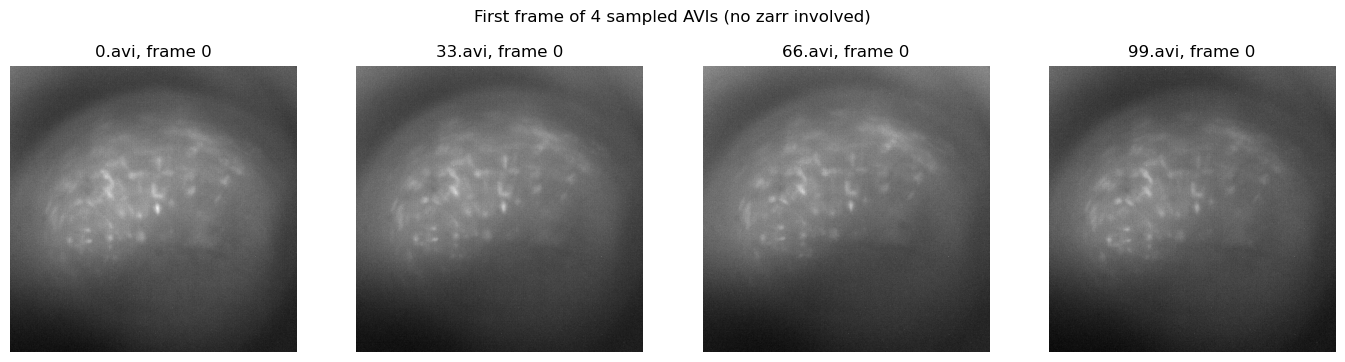

In [4]:
# Pull a few evenly-spaced frames straight from the AVIs (no zarr).
# Reuses the same luma-gray decoder the MC path will use.
import av

def _decode_first_frame(avi_path: Path) -> np.ndarray:
    container = av.open(str(avi_path))
    try:
        stream = container.streams.video[0]
        stream.thread_type = 'FRAME'
        for frame in container.decode(stream):
            return frame.to_ndarray(format='gray8')
    finally:
        container.close()
    raise RuntimeError(f'{avi_path} has no frames')

sample_picks = np.linspace(0, len(avis) - 1, 4).astype(int)
sample = np.stack([_decode_first_frame(avis[i]) for i in sample_picks], axis=0)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, i, img in zip(axes, sample_picks, sample):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{avis[i].name}, frame 0')
    ax.axis('off')
fig.suptitle('First frame of 4 sampled AVIs (no zarr involved)', y=1.02)
plt.tight_layout()
plt.show()

raw inspection sample: (600, 600)  (decoded 24.3s)


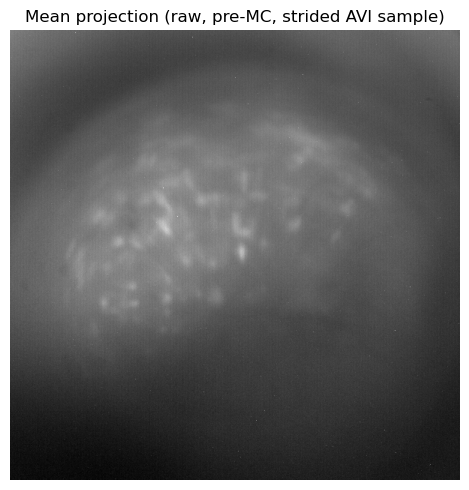

In [5]:
# Coarse raw mean projection: decode every Nth frame from ~12 strided AVIs,
# average them in RAM. Light enough to run before MC; gives us a "before"
# baseline for the diagnostic plots later.
def avi_mean_and_median(avi_paths, max_avis: int = 12, stride_within: int = 50):
    """Decode strided frames from a strided AVI subset; return (mean, median)
    images.
    """
    k = min(max_avis, len(avi_paths))
    picks = np.linspace(0, len(avi_paths) - 1, k).astype(int)
    pool = []
    for i in picks:
        container = av.open(str(avi_paths[i]))
        try:
            stream = container.streams.video[0]
            stream.thread_type = 'FRAME'
            for j, frame in enumerate(container.decode(stream)):
                if j % stride_within == 0:
                    pool.append(frame.to_ndarray(format='gray8'))
        finally:
            container.close()
    sampled = np.stack(pool, axis=0).astype(np.float32)
    return sampled.mean(axis=0), np.median(sampled, axis=0)

t0 = time.time()
raw_mean, raw_tmpl = avi_mean_and_median(avis)
H_raw, W_raw = raw_mean.shape
print(f'raw inspection sample: {raw_mean.shape}  '
      f'(decoded {time.time() - t0:.1f}s)')

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(raw_mean, cmap='gray')
ax.set_title('Mean projection (raw, pre-MC, strided AVI sample)')
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Parameters (native units)

Define the `CNMFeParams` in **native** (full-resolution) units. Section 5
rescales them to the downsampled grid with `params.downscaled(SSUB, TSUB)`.

In [21]:
# Parameters in NATIVE (full-resolution) units. When SSUB/TSUB > 1 they are
# rescaled to the downsampled grid via params.downscaled(SSUB, TSUB) in the
# next cell, and the rescaled copy drives both MC and extraction.
params = CNMFeParams(
    # --- motion correction ---
    max_shift=(20, 20),
    upsample_factor=10,
    mc_n_iter=1,                   # fused AVI->MC path supports 1 only
    mc_gSig_filt=7,                # 1p high-pass sigma; set None for 2p
    mc_batch_size=1000,
    mc_template_max_frames=2000,
    mc_output_chunk_t=None,        # default = mc_batch_size
    mc_output_dtype='float32',
    # --- CNMFe extraction ---
    sigma=5.0,
    min_corr=0.8,
    min_pnr=10.0,
    n_iter_main=1,
    n_iter_temporal=2,
    merge_thr_corr=0.85,
    merge_thr_overlap=0.5,
    spatial_max_thr=0.1,
    n_jobs=-1,
    decay_time_ms=180,
    frame_rate_hz=20,
    g_prior_weight=0.95,
    global_ar=False,
    spatial_max_iter = 4000,
)

# CNMFeParams.spatial_max_iter
print(f'native params: sigma={params.sigma} max_shift={params.max_shift} '
      f'mc_gSig_filt={params.mc_gSig_filt}')

native params: sigma=5.0 max_shift=(20, 20) mc_gSig_filt=7


## 5. Motion correction — fused AVI → `mc.zarr` (+ optional downsample)

`fit_mc_from_avis` decodes the AVIs, bins them **inline** when `SSUB`/`TSUB` > 1,
and rigid-motion-corrects in one streaming pass — writing only `mc.zarr`
(float32) + `shifts.npy`. No intermediate `session.zarr` / `ds.zarr`. Peak RAM
≈ `(mc_batch_size + mc_template_max_frames) * H_out * W_out * 4` bytes,
independent of T.

`params_eff = params.downscaled(SSUB, TSUB)` rescales `max_shift` /
`mc_gSig_filt` (and `sigma`, `min_pixel`, ...) to the binned grid; the same
`params_eff` drives extraction. **`mc_n_iter` must be 1** on the fused path
(multi-iteration MC needs the two-step `concat_avis_to_zarr` + `fit_mc` flow).
Idempotent via `skip_if_exists` — delete `mc.zarr` to re-run.

In [22]:
# Rescale native params -> the (possibly downsampled) grid; the same
# params_eff drives both MC and extraction.
params_eff = params.downscaled(SSUB, TSUB)
if DOWNSAMPLE:
    print(f'downsampling ssub={SSUB} tsub={TSUB}:  '
          f'sigma {params.sigma}->{params_eff.sigma},  '
          f'min_pixel {params.min_pixel}->{params_eff.min_pixel},  '
          f'max_shift {params.max_shift}->{params_eff.max_shift},  '
          f'mc_gSig_filt {params.mc_gSig_filt}->{params_eff.mc_gSig_filt}')

# Fused decode (+ inline bin) + MC -> mc.zarr (the only zarr written).
model_mc = CNMFe(params_eff)
t0 = time.time()
mc = model_mc.fit_mc_from_avis(
    RAW_AVI_DIR, output_dir=SESSION_PREPROC,
    ssub=SSUB, tsub=TSUB, skip_if_exists=True,
)
print(f'\nfused decode+MC elapsed: {time.time() - t0:.1f}s')

T_mc, H, W = mc.shape
print(f'mc shape  : {mc.shape}')
print(f'mc chunks : {mc.chunks}')
print(f'mc dtype  : {mc.dtype}')
print(f'shifts    : {None if model_mc.shifts is None else model_mc.shifts.shape}')

downsampling ssub=2 tsub=2:  sigma 5.0->2.5,  min_pixel 3->1,  max_shift (20, 20)->(10, 10),  mc_gSig_filt 7->3.5
Output already exists, reusing: /media/server/archive/projects/2023_intercontext/ToneComparison/data/1_preprocessed/20260520_m0000159_som_1145/miniscope_video/mc.zarr

fused decode+MC elapsed: 0.0s
mc shape  : (49643, 300, 300)
mc chunks : (1000, 300, 300)
mc dtype  : float32
shifts    : (49643, 2)


## 6. MC diagnostics

Three plots, all written to `MC_PLOTS/`:

- **shifts.png** — per-frame `(dy, dx)` over time. Flat-top saturation means
  shifts are hitting `max_shift` — bump `params.max_shift`.
- **mean_before_after.png** — raw mean (strided AVI sample, section 3b) vs the
  corrected mean (streamed over `mc.zarr`). Note: when downsampling, the raw
  sample is at native resolution and `mc.zarr` is at the downsampled grid, so
  the two panels differ in pixel size — compare structure, not scale.
- **template_before_after.png** — same idea, median-based (robust to bursts).

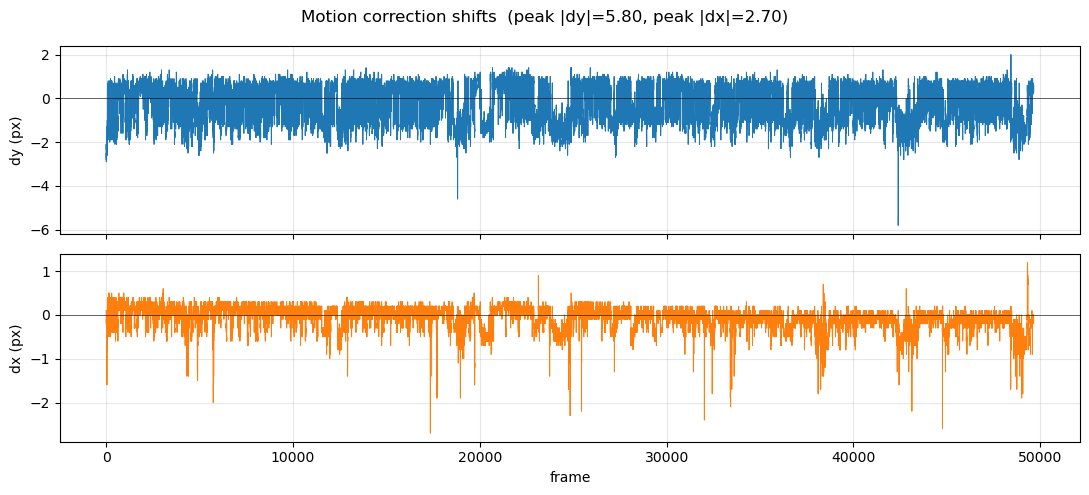

wrote /media/server/archive/projects/2023_intercontext/ToneComparison/data/2_processed/20260520_m0000159_som_1145/miniscope_video/mc_plots/shifts.png


In [8]:
if model_mc.shifts is not None:
    shifts = np.asarray(model_mc.shifts)
    fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    ax[0].plot(shifts[:, 0], lw=0.7)
    ax[0].set_ylabel('dy (px)')
    ax[0].axhline(0, color='k', lw=0.4)
    ax[0].grid(alpha=0.3)
    ax[1].plot(shifts[:, 1], lw=0.7, color='C1')
    ax[1].set_ylabel('dx (px)')
    ax[1].set_xlabel('frame')
    ax[1].axhline(0, color='k', lw=0.4)
    ax[1].grid(alpha=0.3)
    fig.suptitle(f'Motion correction shifts  (peak |dy|={np.abs(shifts[:,0]).max():.2f}, '
                 f'peak |dx|={np.abs(shifts[:,1]).max():.2f})')
    plt.tight_layout()
    out = MC_PLOTS / 'shifts.png'
    fig.savefig(out, dpi=120)
    plt.show()
    print(f'wrote {out}')
else:
    print('no shifts available; skipping plot')

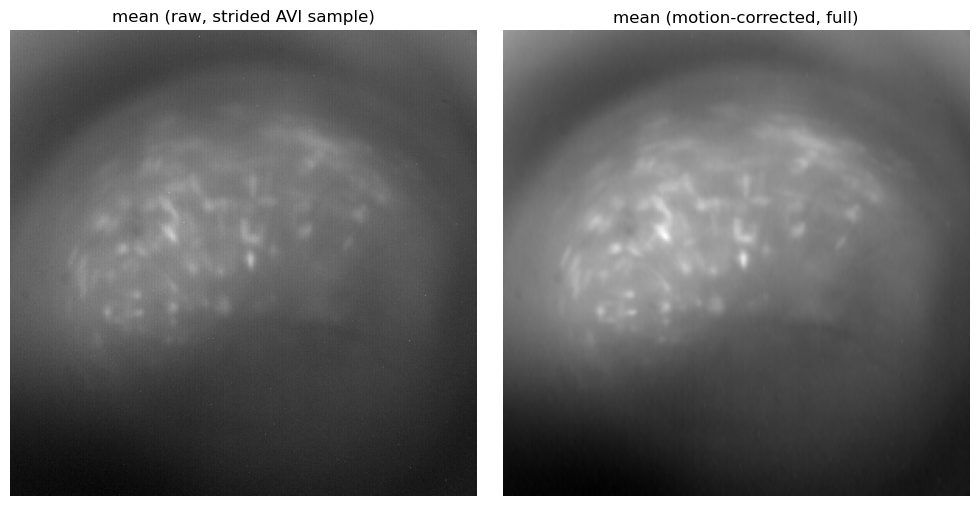

wrote /media/server/archive/projects/2023_intercontext/ToneComparison/data/2_processed/20260520_m0000159_som_1145/miniscope_video/mc_plots/mean_before_after.png


In [9]:
# Corrected mean projection — streamed over the mc.zarr.
def mean_projection(zarr_arr, batch_size: int = 500) -> np.ndarray:
    """Streamed mean projection; RAM ~ batch_size * H * W * 8 bytes."""
    T = zarr_arr.shape[0]
    acc = np.zeros(zarr_arr.shape[1:], dtype=np.float64)
    for start in range(0, T, batch_size):
        end = min(start + batch_size, T)
        acc += np.asarray(zarr_arr[start:end], dtype=np.float64).sum(axis=0)
    return (acc / T).astype(np.float32)

mc_mean = mean_projection(mc)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw_mean, cmap='gray')
axes[0].set_title('mean (raw, strided AVI sample)')
axes[0].axis('off')
axes[1].imshow(mc_mean, cmap='gray')
axes[1].set_title('mean (motion-corrected, full)')
axes[1].axis('off')
plt.tight_layout()
out = MC_PLOTS / 'mean_before_after.png'
fig.savefig(out, dpi=120)
plt.show()
print(f'wrote {out}')

In [10]:
# # Corrected median template — strided sample of mc.zarr.
# def strided_median(zarr_arr, max_frames: int = 800) -> np.ndarray:
#     """Median projection from a strided sample — robust to bright transients."""
#     T = zarr_arr.shape[0]
#     idx = np.linspace(0, T - 1, min(T, max_frames)).astype(int)
#     sample = np.stack([np.asarray(zarr_arr[i]) for i in idx], axis=0)
#     return np.median(sample.astype(np.float32), axis=0)
#
# mc_tmpl = strided_median(mc)
#
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# axes[0].imshow(raw_tmpl, cmap='gray')
# axes[0].set_title('median template (raw, strided AVI sample)')
# axes[0].axis('off')
# axes[1].imshow(mc_tmpl, cmap='gray')
# axes[1].set_title('median template (motion-corrected, full)')
# axes[1].axis('off')
# plt.tight_layout()
# out = MC_PLOTS / 'template_before_after.png'
# fig.savefig(out, dpi=120)
# plt.show()
# print(f'wrote {out}')

## 7. Downsampled MC video for visual QC

Every Nth frame of the corrected zarr written as a small mp4, intensity
normalised to the 0.5–99.5 percentile range. Idempotent: skips if the mp4
already exists.

In [11]:
STRIDE  = 20        # save every 10th frame
FPS_OUT = 50.0      # playback speed of the produced mp4

if MC_MP4.exists():
    print(f'{MC_MP4} already exists, skipping (delete to re-render)')
else:
    idx = np.arange(0, T_mc, STRIDE)
    print(f'rendering {len(idx)} frames (every {STRIDE}th of {T_mc})...')

    # Streaming percentile estimate from a sample to set robust display range.
    sample = np.stack([np.asarray(mc[i]) for i in np.linspace(0, T_mc - 1, 200).astype(int)])
    lo = float(np.percentile(sample, 0.5))
    hi = float(np.percentile(sample, 99.5))
    print(f'display range: [{lo:.2f}, {hi:.2f}]')

    import cv2
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    H_mc, W_mc = mc.shape[1], mc.shape[2]
    writer = cv2.VideoWriter(str(MC_MP4), fourcc, FPS_OUT, (W_mc, H_mc), isColor=False)
    if not writer.isOpened():
        raise RuntimeError(f'cv2.VideoWriter failed to open {MC_MP4}')

    t0 = time.time()
    try:
        for k, i in enumerate(idx):
            frame = np.asarray(mc[int(i)], dtype=np.float32)
            frame = np.clip((frame - lo) / (hi - lo + 1e-8), 0.0, 1.0)
            writer.write((frame * 255).astype(np.uint8))
            if (k + 1) % 200 == 0:
                print(f'  wrote {k + 1} / {len(idx)} frames')
    finally:
        writer.release()

    print(f'\nwrote {MC_MP4}  ({time.time() - t0:.1f}s)')

/media/server/archive/projects/2023_intercontext/ToneComparison/data/2_processed/20260520_m0000159_som_1145/miniscope_video/mc_downsampled.mp4 already exists, skipping (delete to re-render)


## 8. CNMFe extraction (staged: `fit_extract` + `evaluate`)

Runs extraction on `mc.zarr` (already at the downsampled resolution) using the
rescaled `params_eff`. The movie is materialised in RAM here; for very long
recordings switch to the streaming path in
`demo_notebooks/02_extract_components.ipynb` (Section 9).

`fit_extract(movie, evaluate=False)` runs greedy init → ring background →
spatial/temporal/merge BCD → final temporal pass + YrA; `model.evaluate()` then
tags components non-destructively (`accepted_mask`). A single
`CNMFe.fit(movie, do_motion_correction=False)` does both in one call.

If the results folder already contains `manifest.json` we reload it instead of
re-running.

In [23]:
if (RESULTS_DIR / 'manifest.json').exists():
    print(f'results already present in {RESULTS_DIR}; reloading')
    print('(delete manifest.json to re-run)')
    model = CNMFe.load(RESULTS_DIR)
else:
    ram_gb = T_mc * H * W * 4 / 1e9
    print(f'loading mc.zarr into RAM ({T_mc} x {H} x {W} float32 ~ {ram_gb:.1f} GB)...')
    t0 = time.time()
    movie = np.asarray(mc, dtype=np.float32)
    print(f'  loaded in {time.time() - t0:.1f}s')

    # Staged extraction on the (possibly downsampled) corrected movie.
    t0 = time.time()
    model = CNMFe(params_eff)

    # model.fit_extract(mc, output_dir=SESSION_PREPROC, evaluate=False)

    model.fit_extract(movie, evaluate=False)   # init -> bg -> BCD -> final temporal
    model.evaluate()                           # non-destructive component tagging
    elapsed = time.time() - t0
    print(f'\nextracted {model.A.shape[1]} components in {elapsed:.1f}s')

    model.save(RESULTS_DIR)
    (RESULTS_DIR / 'run_info.json').write_text(json.dumps({
        'session_raw' : str(SESSION_RAW),
        'mc_zarr'     : str(MC_ZARR),
        'movie_shape' : [int(T_mc), int(H), int(W)],
        'ssub'        : SSUB,
        'tsub'        : TSUB,
        'K_extracted' : int(model.A.shape[1]),
        'wall_time_s' : round(elapsed, 2),
    }, indent=2))
    print(f'saved -> {RESULTS_DIR}')

loading mc.zarr into RAM (49643 x 300 x 300 float32 ~ 17.9 GB)...
  loaded in 86.5s
Extraction config: n_jobs=-1 device=cpu T=49643 H=300 W=300 streaming=no (movie materialised in RAM)
Estimating noise...
Running greedy CORR-PNR initialization (init_stride=9, T_init=5516; corrpnr_stride=2, T_corrpnr=2758)...
Using Bayesian g prior: decay_time_ms=180 frame_rate_hz=10.0 -> g_target=0.5738 (weight=0.95)
  Found 92 initial components.
Fitting ring-model background (radius=9.0px, tsub=5)...
Refinement iteration 1/1...
  Pre-merging duplicate seeds...
  70 components (18 pre-merged).
  Updating spatial footprints...
  update_spatial: 2184/90000 pixels hit max_iter=1000 before converging (tol=0.0001). Increase CNMFeParams.spatial_max_iter or loosen spatial_tol to tighten.
  Updating temporal traces...
  Merging correlated components...
  69 components (1 merged).
Final temporal update...
Done. Extracted 69 neurons.
Auto-evaluation: 68/69 accepted (flagged 1: 0 fail pixel_count<1, 1 fail snr_a

## 9. Inspect results

- Footprints overlaid on the mean image (red = auto-accepted, grey = rejected).
- A handful of representative traces (`C`, `C + YrA`, `S`).

Both plots are written to `MC_PLOTS/`. All coordinates are on the (downsampled)
extraction grid.

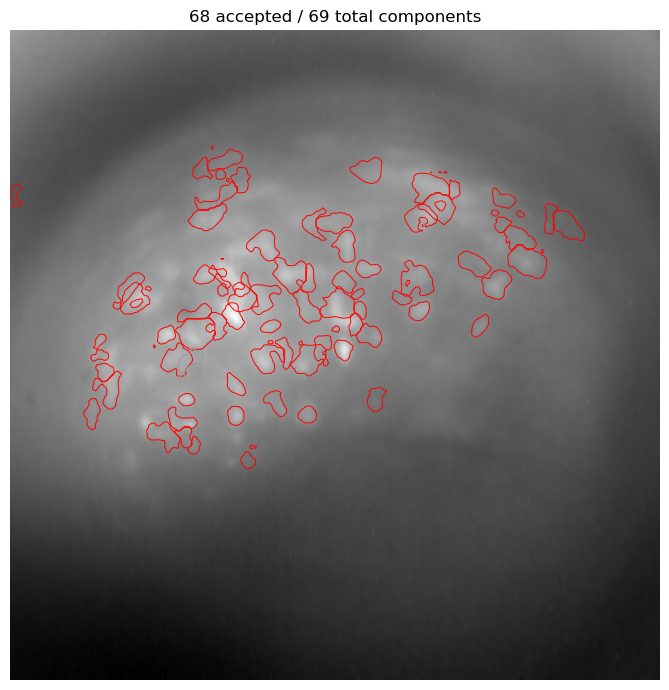

wrote /media/server/archive/projects/2023_intercontext/ToneComparison/data/2_processed/20260520_m0000159_som_1145/miniscope_video/mc_plots/footprints_overlay.png


In [24]:
K = model.A.shape[1]
A_dense = np.asarray(model.A.todense()).reshape(H, W, K)
accepted = getattr(model, 'accepted_mask', np.ones(K, dtype=bool))

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(mc_mean, cmap='gray')
for k in range(K):
    fp = A_dense[..., k]
    if fp.max() <= 0:
        continue
    color = 'red' if accepted[k] else '0.6'
    ax.contour(fp, levels=[fp.max() * 0.3], colors=color, linewidths=0.7)
ax.set_title(f'{int(accepted.sum())} accepted / {K} total components')
ax.axis('off')
plt.tight_layout()
out = MC_PLOTS / 'footprints_overlay.png'
fig.savefig(out, dpi=120)
plt.show()
print(f'wrote {out}')

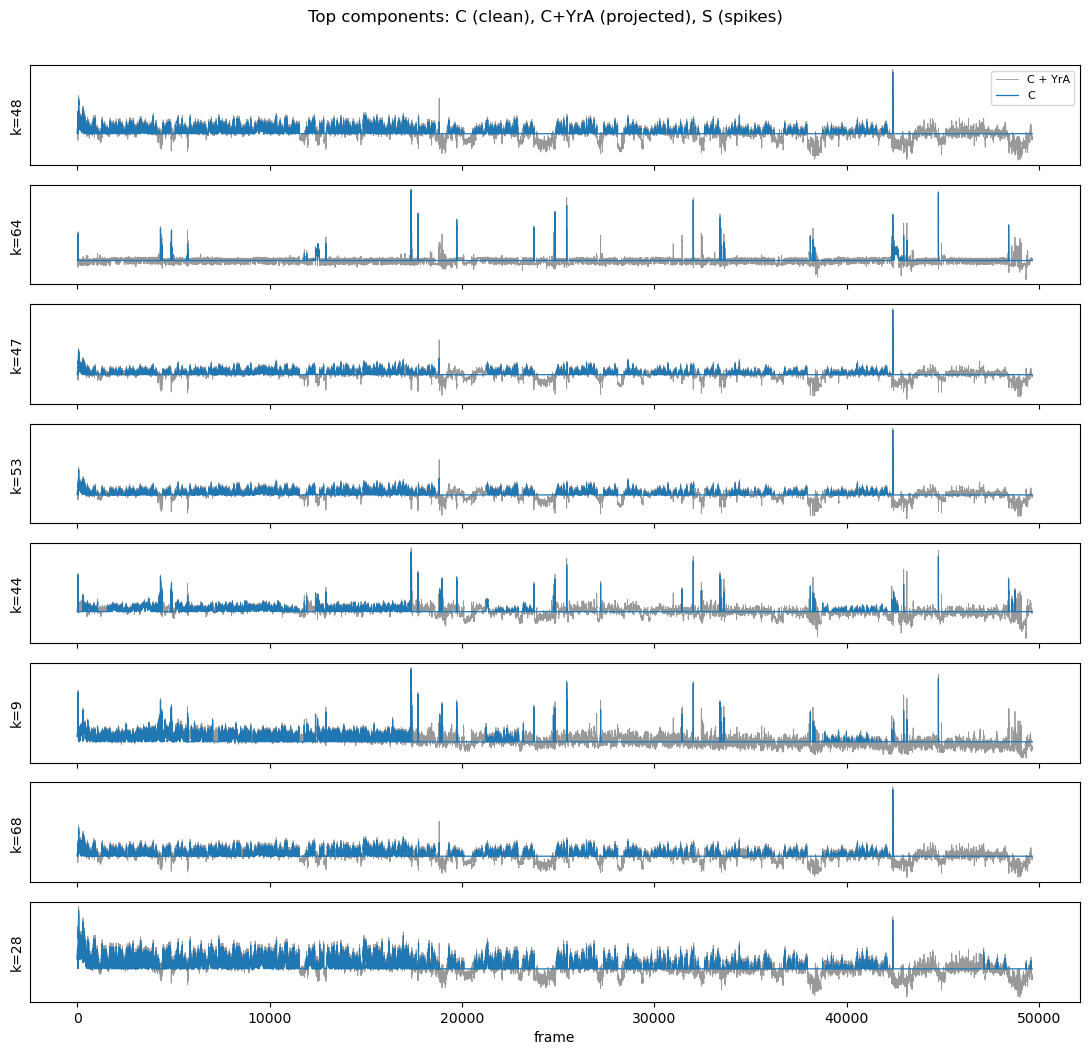

wrote /media/server/archive/projects/2023_intercontext/ToneComparison/data/2_processed/20260520_m0000159_som_1145/miniscope_video/mc_plots/traces.png


In [26]:
n_show = min(8, K)
if n_show == 0:
    print('no components to plot')
else:
    # Show the top-n_show by trace amplitude among accepted components.
    accepted_idx = np.where(accepted)[0]
    pool = accepted_idx if accepted_idx.size else np.arange(K)
    order = pool[np.argsort(-(model.C[pool]).max(axis=1))][:n_show]

    fig, axes = plt.subplots(n_show, 1, figsize=(11, 1.3 * n_show), sharex=True)
    if n_show == 1:
        axes = [axes]
    for ax, k in zip(axes, order):
        proj = model.C[k] + model.YrA[k]
        ax.plot(proj, color='0.6', lw=0.6, label='C + YrA')
        ax.plot(model.C[k], color='C0', lw=0.9, label='C')
        # s = model.S[k]
        # if s.max() > 0:
        #     ax.vlines(np.where(s > 0)[0], 0, model.C[k].max(),
        #               color='C3', lw=0.5, alpha=0.4)
        ax.set_ylabel(f'k={k}')
        ax.set_yticks([])
    axes[0].legend(loc='upper right', fontsize=8)
    axes[-1].set_xlabel('frame')
    fig.suptitle('Top components: C (clean), C+YrA (projected), S (spikes)', y=1.01)
    plt.tight_layout()
    out = MC_PLOTS / 'traces.png'
    fig.savefig(out, dpi=120)
    plt.show()
    print(f'wrote {out}')

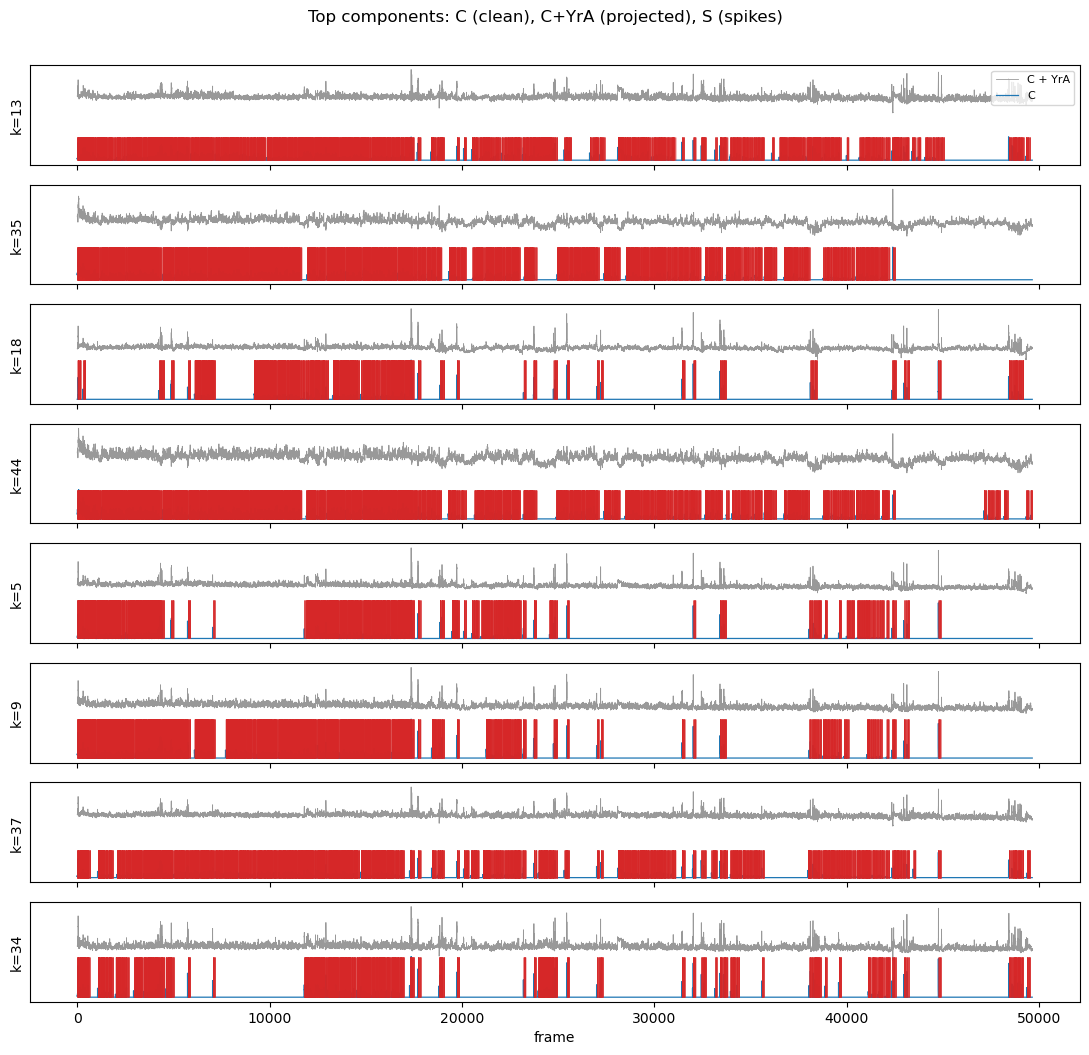

wrote /media/server/archive/projects/2023_intercontext/ToneComparison/data/2_processed/20260520_m0000159_som_1145/miniscope_video/mc_plots/traces.png


In [16]:
n_show = min(8, K)
if n_show == 0:
    print('no components to plot')
else:
    # Show the top-n_show by trace amplitude among accepted components.
    accepted_idx = np.where(accepted)[0]
    pool = accepted_idx if accepted_idx.size else np.arange(K)
    order = pool[np.argsort(-(model.C[pool]).max(axis=1))][:n_show]

    fig, axes = plt.subplots(n_show, 1, figsize=(11, 1.3 * n_show), sharex=True)
    if n_show == 1:
        axes = [axes]
    for ax, k in zip(axes, order):
        proj = model.C[k] + model.YrA[k]
        ax.plot(proj, color='0.6', lw=0.6, label='C + YrA')
        ax.plot(model.C[k], color='C0', lw=0.9, label='C')
        s = model.S[k]
        if s.max() > 0:
            ax.vlines(np.where(s > 0)[0], 0, model.C[k].max(),
                      color='C3', lw=0.5, alpha=0.4)
        ax.set_ylabel(f'k={k}')
        ax.set_yticks([])
    axes[0].legend(loc='upper right', fontsize=8)
    axes[-1].set_xlabel('frame')
    fig.suptitle('Top components: C (clean), C+YrA (projected), S (spikes)', y=1.01)
    plt.tight_layout()
    out = MC_PLOTS / 'traces.png'
    fig.savefig(out, dpi=120)
    plt.show()
    print(f'wrote {out}')

## 10. Re-upsample to native resolution (optional)

`model.upsample_to_native(...)` returns a NEW model with footprints (bilinear)
and continuous traces (linear) interpolated back to the native grid / frame
rate — for overlaying on a native reference image and plotting against
native-rate signals. It is **interpolation, not recovery**: the native movie is
gone in the downsample-once workflow, so no discarded detail comes back. The
deconvolved spike train `S` stays at the downsampled rate and the background
model is dropped (this model is for inspection/overlay, not re-fitting).

native  A: (360000, 69)  C: (69, 99287)  dims=(600, 600)
(downsampled  A: (90000, 69)  C: (69, 49643))


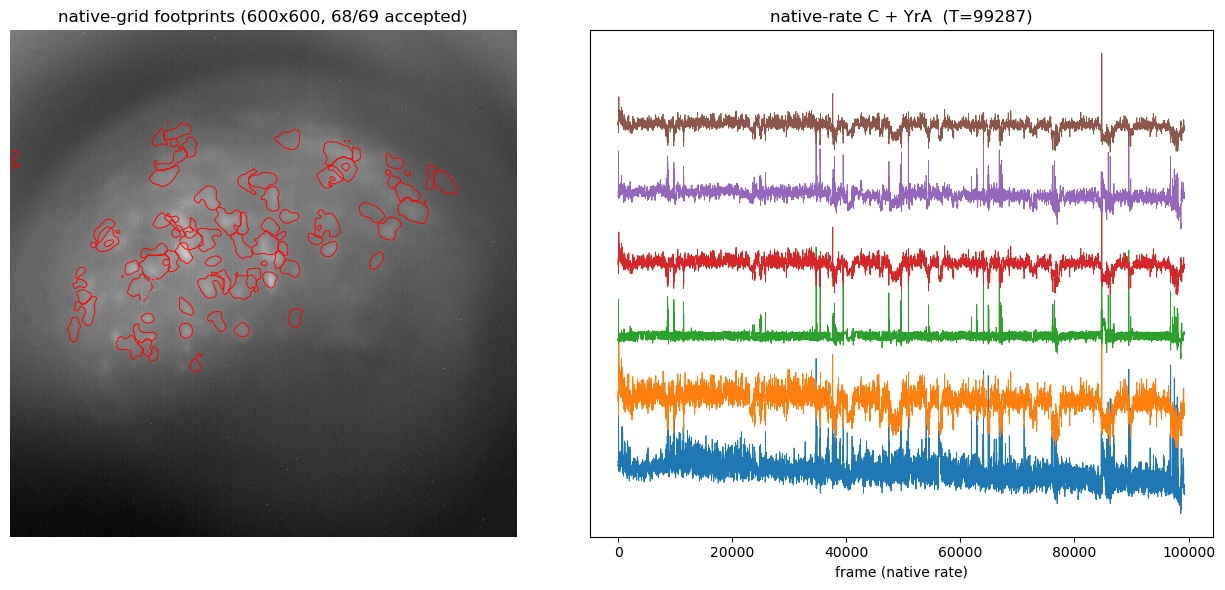

wrote /media/server/archive/projects/2023_intercontext/ToneComparison/data/2_processed/20260520_m0000159_som_1145/miniscope_video/mc_plots/native_footprints_traces.png


In [27]:
# Re-express the downsampled results on the NATIVE grid / frame rate.
# `raw_mean` (native, section 3b) and `total` (native frame count, section 3a)
# give the native dims / T.
model_native = model.upsample_to_native(
    ssub=SSUB, tsub=TSUB, orig_dims=raw_mean.shape, orig_T=total,
)
print(f'native  A: {model_native.A.shape}  C: {model_native.C.shape}  '
      f'dims={model_native.dims}')
print(f'(downsampled  A: {model.A.shape}  C: {model.C.shape})')

Kn = model_native.A.shape[1]
A_nat = np.asarray(model_native.A.todense()).reshape(*model_native.dims, Kn)
acc = getattr(model_native, 'accepted_mask', None)
if acc is None:
    acc = np.ones(Kn, dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
# Left: native-grid footprints over the native raw mean.
axes[0].imshow(raw_mean, cmap='gray')
for k in range(Kn):
    fp = A_nat[..., k]
    if fp.max() <= 0:
        continue
    axes[0].contour(fp, levels=[fp.max() * 0.3],
                    colors='red' if acc[k] else '0.6', linewidths=0.7)
axes[0].set_title(f'native-grid footprints '
                  f'({model_native.dims[0]}x{model_native.dims[1]}, '
                  f'{int(acc.sum())}/{Kn} accepted)')
axes[0].axis('off')

# Right: a few native-rate projected traces (C + YrA at the native frame count).
proj = model_native.C + model_native.YrA          # (K, native_T)
order = np.argsort(-proj.max(axis=1))[:min(6, Kn)]
step = float(proj.max()) * 0.6 if Kn else 1.0
for j, k in enumerate(order):
    axes[1].plot(proj[k] + j * step, lw=0.6)
axes[1].set_title(f'native-rate C + YrA  (T={proj.shape[1]})')
axes[1].set_xlabel('frame (native rate)')
axes[1].set_yticks([])
plt.tight_layout()
out = MC_PLOTS / 'native_footprints_traces.png'
fig.savefig(out, dpi=120)
plt.show()
print(f'wrote {out}')

## Output summary

All artifacts for this session:

```
1_preprocessed/<session>/miniscope_video/
  mc.zarr                     # motion-corrected float32 — the ONLY zarr written
  shifts.npy                  # (T_out, 2) per-frame (dy, dx)

2_processed/<session>/miniscope_video/
  mc_plots/   shifts.png  mean_before_after.png  template_before_after.png
              footprints_overlay.png  traces.png  native_footprints_traces.png
  mc_downsampled.mp4          # every Nth frame, normalised
  results/    A.npz  C.npy  S.npy  YrA.npy  C_raw.npy
              sn.npy  sn_per_k.npy  g.npy  b0.npy  W.npz
              accepted_mask.npy  eval_info.npz
              params.json  manifest.json  run_info.json
```

Outputs (footprints + traces) are at the **downsampled** resolution
(`SSUB`/`TSUB`); the factors are recorded in `run_info.json`. The fused
`fit_mc_from_avis` decodes, bins, and motion-corrects in one pass, so `mc.zarr`
is the only movie written — no `session.zarr` or `ds.zarr`. Reload:

```python
from cnmfe.pipeline import CNMFe
model = CNMFe.load('/.../2_processed/<session>/miniscope_video/results')
A, C, S, YrA = model.A, model.C, model.S, model.YrA
# Re-tag with different thresholds without re-extracting:
model.params.auto_eval_snr_amp_thr = 5.0
model.evaluate()
```

In [ ]:
plt.plot(model.C_projected[10])